## Grupo: 4

## Integrantes:
- Cauê Pileckas
- Diogo Diniz
- Verônica Luisa
- Raymond Lisbona

## Códigos preparatórios

In [1]:
import pandas as pd
import plotly.graph_objects as go
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
data = pd.read_excel('sistema2.xlsx', skiprows=39)
data.head()

,Scan Sweep Time (Sec),Scan Number,101Time (Sec),101 (°C),102Time (Sec),102 (°C),103Time (Sec),103 (°C),104Time (Sec),104 (°C),...,113Time (Sec),113 (°C),114Time (Sec),114 (°C),115Time (Sec),115 (°C),116Time (Sec),116 (°C),117Time (Sec),117 (Vac)
0,2024-09-16 08:33:44.090,1,2024-09-16 08:33:44.090,16.621,2024-09-16 08:33:44.129,15.590,2024-09-16 08:33:44.169,15.628,2024-09-16 08:33:44.208,15.628,...,2024-09-16 08:33:44.559,15.785,2024-09-16 08:33:44.598,16.588,2024-09-16 08:33:44.637,16.911,2024-09-16 08:33:44.676,16.961,2024-09-16 08:33:45.874,0.000001
1,2024-09-16 08:33:54.074,2,2024-09-16 08:33:54.074,16.768,2024-09-16 08:33:54.113,15.648,2024-09-16 08:33:54.153,15.647,2024-09-16 08:33:54.192,15.732,...,2024-09-16 08:33:54.542,15.806,2024-09-16 08:33:54.580,16.584,2024-09-16 08:33:54.619,16.902,2024-09-16 08:33:54.658,16.866,2024-09-16 08:33:55.854,0.000000
2,2024-09-16 08:34:04.074,3,2024-09-16 08:34:04.074,16.712,2024-09-16 08:34:04.113,15.699,2024-09-16 08:34:04.152,15.686,2024-09-16 08:34:04.191,15.675,...,2024-09-16 08:34:04.540,15.811,2024-09-16 08:34:04.579,16.603,2024-09-16 08:34:04.618,16.920,2024-09-16 08:34:04.657,16.976,2024-09-16 08:34:05.855,0.000000
3,2024-09-16 08:34:14.074,4,2024-09-16 08:34:14.074,16.699,2024-09-16 08:34:14.113,15.611,2024-09-16 08:34:14.153,15.649,2024-09-16 08:34:14.192,15.644,...,2024-09-16 08:34:14.542,15.798,2024-09-16 08:34:14.581,16.611,2024-09-16 08:34:14.620,16.923,2024-09-16 08:34:14.658,16.995,2024-09-16 08:34:15.855,0.000000
4,2024-09-16 08:34:24.075,5,2024-09-16 08:34:24.075,16.708,2024-09-16 08:34:24.114,15.619,2024-09-16 08:34:24.153,15.683,2024-09-16 08:34:24.192,15.664,...,2024-09-16 08:34:24.543,15.802,2024-09-16 08:34:24.582,16.579,2024-09-16 08:34:24.621,16.912,2024-09-16 08:34:24.659,16.924,2024-09-16 08:34:25.859,0.000000


In [3]:
data.columns

Index(['Scan Sweep Time (Sec)', 'Scan Number', '101Time (Sec)', '101 (°C)',
       '102Time (Sec)', '102 (°C)', '103Time (Sec)', '103 (°C)',
       '104Time (Sec)', '104 (°C)', '105Time (Sec)', '105 (°C)',
       '106Time (Sec)', '106 (°C)', '107Time (Sec)', '107 (°C)',
       '108Time (Sec)', '108 (°C)', '109Time (Sec)', '109 (°C)',
       '110Time (Sec)', '110 (°C)', '111Time (Sec)', '111 (°C)',
       '112Time (Sec)', '112 (°C)', '113Time (Sec)', '113 (°C)',
       '114Time (Sec)', '114 (°C)', '115Time (Sec)', '115 (°C)',
       '116Time (Sec)', '116 (°C)', '117Time (Sec)', '117 (Vac)'],
      dtype='object')

In [4]:
data_estacionaria = data.iloc[5000:8000]
data_estacionaria.head()

,Scan Sweep Time (Sec),Scan Number,101Time (Sec),101 (°C),102Time (Sec),102 (°C),103Time (Sec),103 (°C),104Time (Sec),104 (°C),...,113Time (Sec),113 (°C),114Time (Sec),114 (°C),115Time (Sec),115 (°C),116Time (Sec),116 (°C),117Time (Sec),117 (Vac)
5000,2024-09-16 22:27:04.079,5001,2024-09-16 22:27:04.079,15.832,2024-09-16 22:27:04.118,31.570,2024-09-16 22:27:04.156,31.411,2024-09-16 22:27:04.195,31.042,...,2024-09-16 22:27:04.546,29.764,2024-09-16 22:27:04.585,22.352,2024-09-16 22:27:04.624,16.437,2024-09-16 22:27:04.663,16.070,2024-09-16 22:27:05.861,8.831019
5001,2024-09-16 22:27:14.074,5002,2024-09-16 22:27:14.074,15.685,2024-09-16 22:27:14.113,31.478,2024-09-16 22:27:14.153,31.394,2024-09-16 22:27:14.192,31.027,...,2024-09-16 22:27:14.542,29.737,2024-09-16 22:27:14.581,22.338,2024-09-16 22:27:14.619,16.377,2024-09-16 22:27:14.658,16.161,2024-09-16 22:27:15.856,8.842993
5002,2024-09-16 22:27:24.077,5003,2024-09-16 22:27:24.077,15.587,2024-09-16 22:27:24.116,31.454,2024-09-16 22:27:24.155,31.379,2024-09-16 22:27:24.194,30.996,...,2024-09-16 22:27:24.544,29.779,2024-09-16 22:27:24.583,22.413,2024-09-16 22:27:24.621,16.452,2024-09-16 22:27:24.660,16.060,2024-09-16 22:27:25.859,8.837491
5003,2024-09-16 22:27:34.074,5004,2024-09-16 22:27:34.074,15.370,2024-09-16 22:27:34.113,31.592,2024-09-16 22:27:34.152,31.423,2024-09-16 22:27:34.191,31.003,...,2024-09-16 22:27:34.542,29.781,2024-09-16 22:27:34.580,22.452,2024-09-16 22:27:34.620,16.540,2024-09-16 22:27:34.659,16.174,2024-09-16 22:27:35.857,8.830479
5004,2024-09-16 22:27:44.074,5005,2024-09-16 22:27:44.074,15.375,2024-09-16 22:27:44.113,31.422,2024-09-16 22:27:44.152,31.343,2024-09-16 22:27:44.191,30.991,...,2024-09-16 22:27:44.541,29.793,2024-09-16 22:27:44.580,22.472,2024-09-16 22:27:44.619,16.628,2024-09-16 22:27:44.658,16.595,2024-09-16 22:27:45.856,8.834816


In [5]:
canais = [f"{x} (°C)" for x in range(101, 117)]

data_medias_distancias = pd.DataFrame()
data_medias_distancias["Chanel"] = [column for column in canais]
data_medias_distancias["T - Mean [˚C]"] = [data_estacionaria[column].mean() for column in canais]
data_medias_distancias["Distance [mm]"] = [x for x in range(-15, 182-16, 15)] + [None, None, None]
data_medias_distancias

,Chanel,T - Mean [˚C],Distance [mm]
0,101 (°C),15.689968,-15.0
1,102 (°C),31.394970,0.0
2,103 (°C),31.280760,15.0
3,104 (°C),30.917629,30.0
4,105 (°C),30.720313,45.0
5,106 (°C),30.637927,60.0
6,107 (°C),30.449438,75.0
7,108 (°C),30.281326,90.0
8,109 (°C),30.128774,105.0
9,110 (°C),29.958554,120.0


----

## Exercício 1:

Preencha a tabela com as informações do sistema usado pelo grupo.

### Código para EX1

In [6]:
data_filtered_ex1 = data[data['117 (Vac)'] >= 1]['117 (Vac)'].to_frame()
data_filtered_ex1.head()

,117 (Vac)
427,9.381725
428,9.375964
429,8.666271
430,8.646918
431,8.648471


In [7]:
print(f"Tensão: {round(data_filtered_ex1['117 (Vac)'].mean(), 4)}")

Tensão: 8.6827


### Resolução exercício 1

Para resolver o exercício 1: 

Primeiro utilizamos a **resistência elétrica fornecida**.

Para calcular a **tensão aplicada**, fizemos a média dos valores medidos no canal 117 após as primeiras iterações (à partir do momento que ele começou a apresentar valores consideráveis).

| Informações | Valores  |
|----------------------|---|
| Nº do sistema usado:|  2 |
| Resistência elétrica:|  5,56 |
| Tensão aplicada:     | 8,68  |

----

## Exercício 2:

A Figura 2 ilustra a variação da condutividade do alumínio 2014 com a temperatura.  
Verifique a condição de **regime permanente** na aleta, observando os resultados de temperatura.  
Determine e indique em sua resposta:

**a)** A condutividade do alumínio na **temperatura de filme**, definida por:

$$
T_f = \frac{T_{\mathrm{mal}} + T_{\mathrm{mamb}}}{2}
$$

onde:

- $T_{\mathrm{mal}}$ é a **temperatura média na aleta**  
- $T_{\mathrm{mamb}}$ é a **temperatura média ambiente**

### Código para o exercício 2

In [8]:
media_medias = data_medias_distancias.iloc[1:12]["T - Mean [˚C]"].mean()

t_amb_media = data_estacionaria[['101 (°C)']].mean().mean()
t_filme = (media_medias + t_amb_media)/2
t_filme

def interpolador_lagrange(x, x_data, fofx_data):
    f_x = 0
    for i, f in enumerate(fofx_data):
        multiplier = 1.0
        for j, _ in enumerate(x_data):
            if j!=i:
                multiplier *= (x-x_data[j])/(x_data[i]-x_data[j])
        f_x += multiplier*f
    return f_x

x_data = [37.78, 51.67]
fofx_data = [155.68, 156.88]

K = interpolador_lagrange(t_filme, x_data, fofx_data)


print(f"T_mal = {media_medias:.4f} °C")
print(f"T_amb = {t_amb_media:.4f} °C")
print(f"T_filme = {t_filme:.4f} °C")
print(f"""A condutividade térmica do alumínio na temperatura do filme é...\n
K = {K:.2f} W/(m*K)""")

T_mal = 30.4926 °C
T_amb = 15.6900 °C
T_filme = 23.0913 °C
A condutividade térmica do alumínio na temperatura do filme é...

K = 154.41 W/(m*K)


### Resolução e explicação do exercício 2

Para resolver o exercício 2, calculamos a média para cada canal pertencente à aleta (dos valores estacionários), em seguida, fizemos a média das médias, para encontrar $T_{mal}$.

Para encontrar $T_{amb}$, fizemos a média dos valores estacionários do canal 101.

Após os processos, chegamos em:

- $T_{mal}$ = 30.49˚C

- $T_{amb}$ = 15.69˚C

$$
T_f = \frac{{30.49} + {15.69}}{2}
$$

Logo:

$T_f$ = 23.09˚C

Após encontrar $T_f$, devemos fazer a interpolação de lagrange para encontrar o valor da condutividade térmica do alumínio na temperatura $T_f$.

Após aplicar a fórmula descrita no código acima (interpolação de lagrange), chegamos em:

$$
K = 154.41 [ \frac{{W}}{m * K}] 
$$

----

## Exercício 3:
Gráfico 1: Apresente um gráfico da temperatura medida experimentalmente $T_{exp}$ em cada posição do
termopar. Considere que o termopar da base ocupa a posição 𝑥 = 0.

Em sua resposta:

a) Apresente o gráfico de acordo com o solicitado.

### Código para o exercício 3

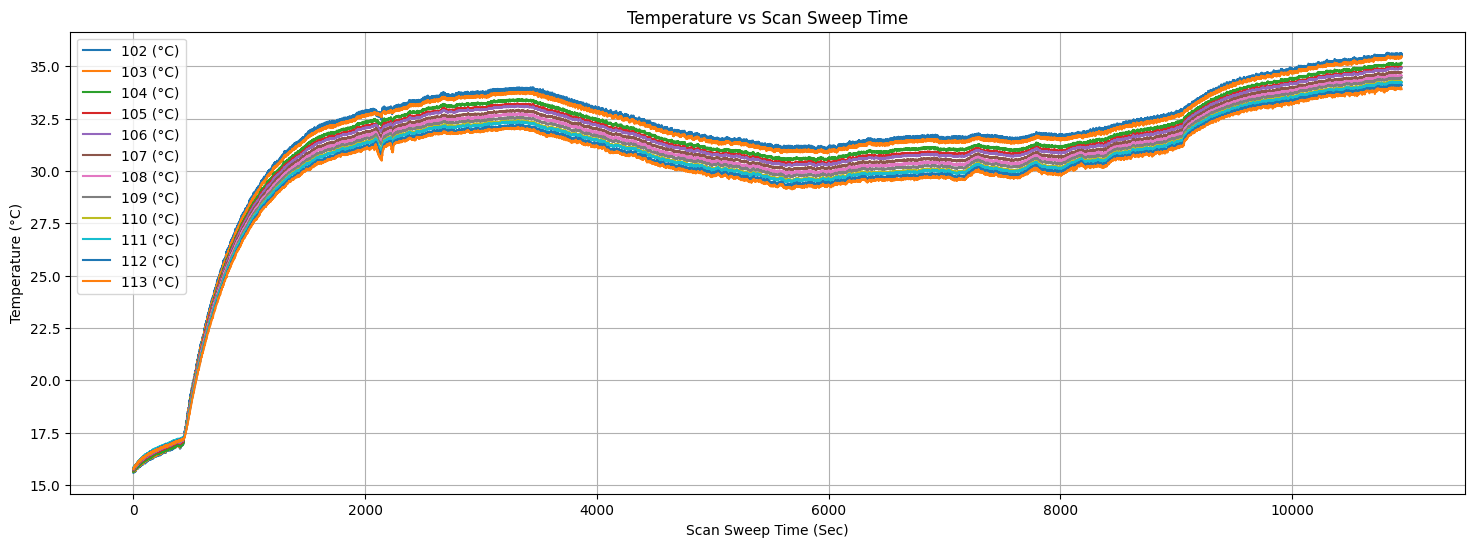

In [9]:
graphic_columns_ex3 = [f"{x} (°C)" for x in range(102, 114)]

plt.figure(figsize=(18, 6))
for column in graphic_columns_ex3:
    plt.plot(data.index, data[column], label=column)
plt.title("Temperature vs Scan Sweep Time")
plt.xlabel("Scan Sweep Time (Sec)")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.legend()
plt.show()

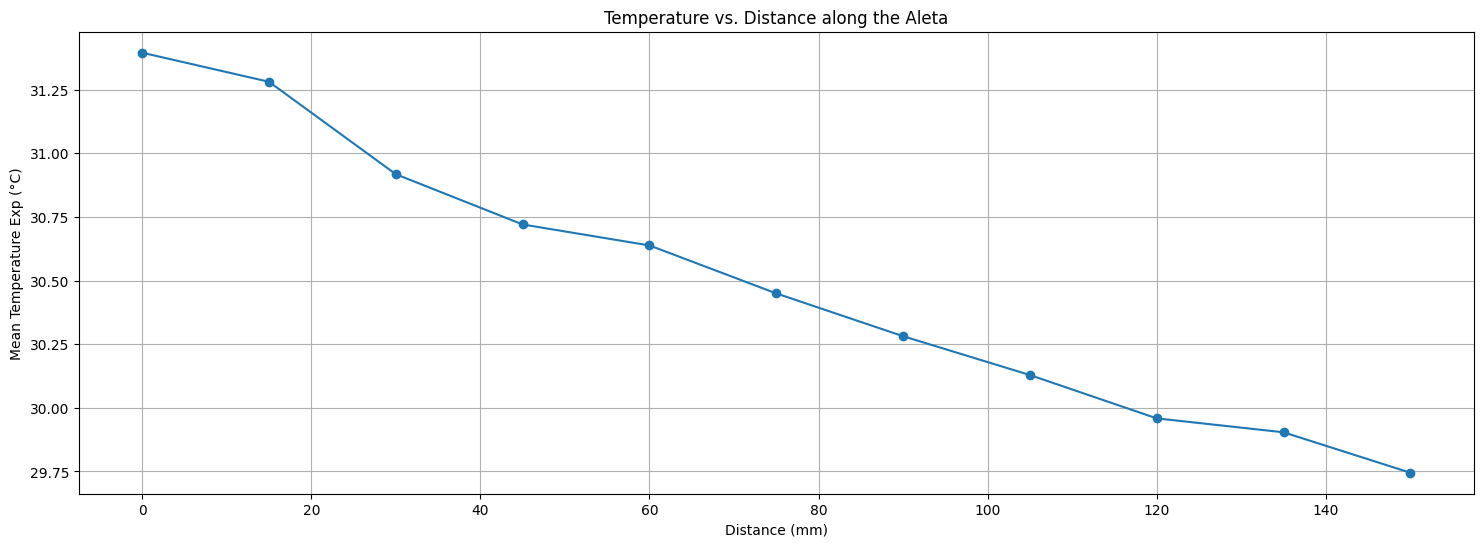

In [10]:
graph_ex3 = data_medias_distancias.iloc[1:12]

plt.figure(figsize=(18, 6))
plt.plot(graph_ex3["Distance [mm]"], graph_ex3["T - Mean [˚C]"], marker='o', linestyle='-')
plt.title("Temperature vs. Distance along the Aleta")
plt.xlabel("Distance (mm)")
plt.ylabel("Mean Temperature Exp (°C)")
plt.grid(True)
plt.show()

### Resolução e Explicação exercício 3
1. Utilizamos os canais de 102 a 113 pois representam desde a base da aleta até seu topo (todos os canais internos);

2. Como podemos observar no gráfico "Temperature vs Scan Sweep Time", pode ser considerado o regime permanente da iteração 5000 até a 8000. Logo, para resolver as questões utilizaremos a média desses valores medidos;

3. Para plotar o gráfico corretamente, consideramos o canal 102 como a base da aleta (x = 0). Logo, utilizando as figuras fornecidas no arquivo do projeto, tivemos de reduzir as distâncias da distância que o canal 102 estava (16mm) para encontrar a distância de cada canal do canal 102;

4. O último passo foi plotar o gráfico com o eixo x sendo a distância em milímetros dos canais 102 a 113 em relação ao canal 102 e com o eixo y sendo a média das temperaturas medidas fornecidas na base do sistema 2.


----

## Exercício 4
<p>
Gráfico 2: Apresente um gráfico da temperatura considerando o modelo analítico (T teórico) ao longo do
comprimento da aleta. Considere a posição do termopar da base como 𝑥 = 0. Em sua resposta:
</p>

<p> 
a. Indique o modelo analítico usado considerando as condições de contorno na base e na extremidade
da aleta.
</p>
<p>
b. Destaque a temperatura na posição do último termopar e na extremidade da aleta. ATENÇÃO:
Observe que o último termopar não está localizado na extremidade da aleta.
</p>
<p>
c. Com base em seus estudos e na montagem da experiência, faça uma estimativa para o parâmetro ℎ
e destaque esse resultado na resposta. Explique brevemente o raciocínio usado para a escolha.
</p>
<p>
d. Apresente o gráfico e indique o valor de 𝒉 usado na figura.
</p>

a) O modelo analítico usado para descrever a distribuição de temperatura ao longo da aleta é baseado na equação da condução de calor em regime permanente, considerando transferência de calor por convecção

Para a condição de contorno da base (x=0)

$$
T(0) = T_b
$$


Para a segunda condição de contorno, na extremidade (x=L) - Convecção, CASO A

$$ - \kappa \frac{d\theta}{dx} \Bigg|_{x=L} = h\theta(L) $$

Logo , a equação de distribuição de temperaturas é :

$$
T(x) = T_{\infty} + (T_0 - T_{\infty}) \cdot \frac{\cosh(m(L - x)) + \left(\frac{h}{m k}\right) \sinh(m(L - x))}{\cosh(mL) + \left(\frac{h}{m k}\right) \sinh(mL)}
$$

b) 

In [11]:
temp_media = data_medias_distancias["T - Mean [˚C]"]
ultima_term = temp_media[11] # 11 -> Termopar 112
print(f"Temperatura no termopar 112: {ultima_term:.4f}˚C") # Último termopar
# temp_media

Temperatura no termopar 112: 29.7450˚C


In [12]:
# Temperatura na extremidade da aleta

dist = data_medias_distancias.iloc[0:12]["Distance [mm]"].values

def temp(x, T1, T2, x1, x2):
    return T1 + ((T2-T1)*(x - x1))/(x2-x1)


T_L = temp(181, temp_media[0], ultima_term , dist[0], dist[-1])

print(f"Na extremidade, a temperatura é: {T_L:.2f} °C")

Na extremidade, a temperatura é: 32.39 °C


c) Com base em seus estudos e na montagem da experiência, faça uma estimativa para o parâmetro ℎ:

In [13]:
h = 15

d) Apresente o gráfico e indique o valor de 𝒉 usado na figura

In [18]:
# graphic_ex4 = data_medias_distancias.iloc[1:13]

calor_esp = 880   
raio = 12*1e-3   
perimetro = 2*math.pi*raio  
densidade = 2794   
At = math.pi*(raio**2)   
L = 0.18

# base = graphic_ex4["T - Mean [˚C]"]
# t_amb_media = data["115 (°C)"].mean() # Temperatura externa/ambiente 
k = 155 # Visto no gráfico

# theta_L = T_L - t_amb_media  # [°C]
m = np.sqrt(h * perimetro / (k * At))

# Função para a distribuição de temperatura
def T(x):
    return (np.cosh(m * (L - x)) + (h / (m * k)) * np.sinh(m * (L - x))) / \
           (np.cosh(m * L) + (h / (m * k)) * np.sinh(m * L))

# Valores de x ao longo da aleta
dist_mm = data_medias_distancias["Distance [mm]"].iloc[:12].values

# converte para metros
x_vals = dist_mm / 1000 

T_base = data_medias_distancias.loc[data_medias_distancias["Chanel"] == "102 (°C)"]["T - Mean [˚C]"].values[0]

T_inf = data_medias_distancias.loc[data_medias_distancias["Chanel"] == "101 (°C)"]["T - Mean [˚C]"].values[0]

def T_analitico(x):
    num = np.cosh(m*(L-x)) + (h/(m*k))*np.sinh(m*(L-x))
    den = np.cosh(m*L)     + (h/(m*k))*np.sinh(m*L)
    ratio = num / den

    return T_inf + (T_base - T_inf)*ratio

x = np.linspace(0, L, 200)
T_x = T_analitico(x)


x_last = x_vals[-1]
T_last = T_analitico(x_last)

T_tip = T_analitico(L)


# ========= verificando h ideal para o experimento =========
def residuo(h):
    m = np.sqrt(h * perimetro / (k * At))
    T_modelo = T_inf + (T_base - T_inf) * np.cosh(m * (L - x_last)) / np.cosh(m * L)
    return T_modelo - T_last  # onde T_last_exp é o valor experimental no último sensor

# Então ajuste h:
from scipy.optimize import root_scalar
sol = root_scalar(residuo, bracket=[1, 100])
h_ideal = sol.root
print("h ideal =", h_ideal)
# =========================================================

h ideal = 15.82904864417691


Temperatura na posição do último termopar (x = 0.150 m): 27.97 °C
Temperatura na extremidade da aleta (x = 0.180 m): 27.85 °C


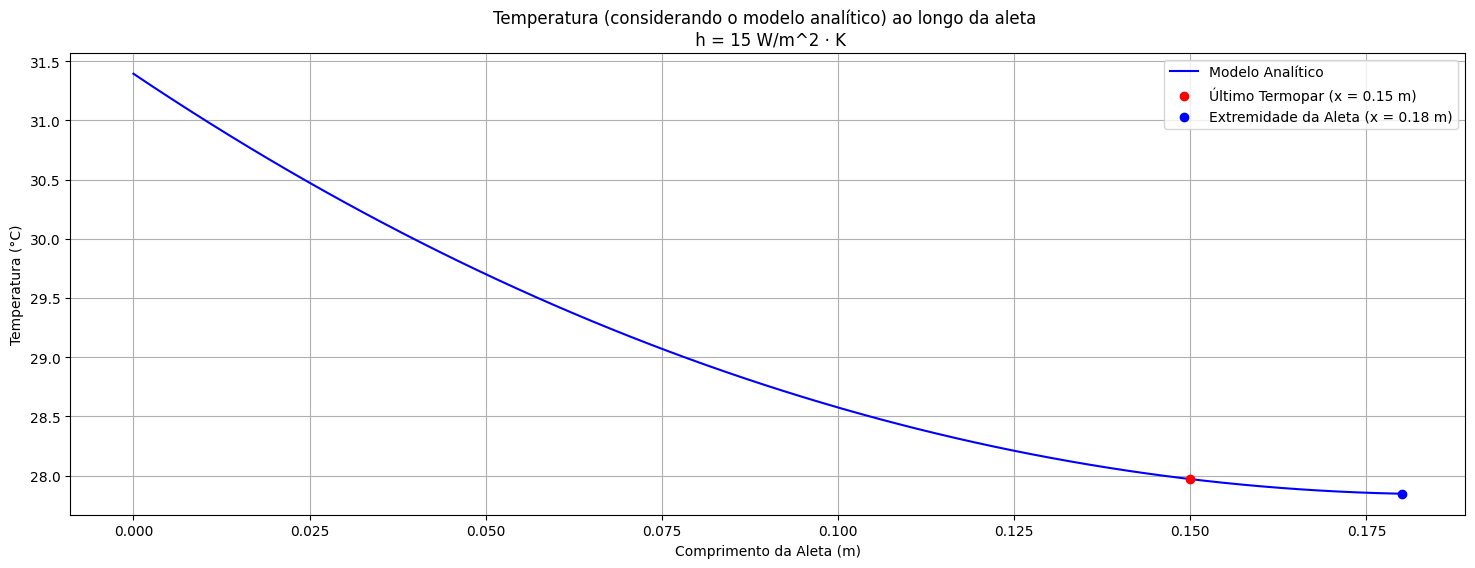

In [19]:
print("Temperatura na posição do último termopar (x = {:.3f} m): {:.2f} °C".format(x_last, T_last))
print("Temperatura na extremidade da aleta (x = {:.3f} m): {:.2f} °C".format(L, T_tip))


plt.figure(figsize=(18, 6))
plt.plot(x, T_x, label='Modelo Analítico', color='blue')
plt.scatter([x_last], [T_last], color='red', zorder=5,
            label=f'Último Termopar (x = {x_last:.2f} m)')
plt.scatter([L], [T_tip], color='blue', zorder=5,
            label=f'Extremidade da Aleta (x = {L:.2f} m)')
plt.xlabel('Comprimento da Aleta (m)')
plt.ylabel('Temperatura (°C)')
plt.title(f'Temperatura (considerando o modelo analítico) ao longo da aleta \n h = {h} W/m^2 · K')
plt.legend()
plt.grid(True)
plt.show()

### Resolução e explicação exercício 4:

1. Para começar a análise do modelo analítico, primeiro identificamos que o modelo estava em regime permanente e analisamos as condições de contornos que fazem parte do sistema; 

2. Descobrimos qual é a temperatura da base (x=0) ;

3. Resolvemos o modelo algébrico (Caso A) e descobrimos a temperatura que estava na extremidade da aleta e no último termopar;

4. Por fim, foi possível plotar um gráfico que compare, a temperatura obtida na extremidade da aleta à temperatura do último termopar.

----

## Exercício 5

### Código para o exercício 5

Δx = 0.013846153846153845 m
Δt = 0.1 s (dt_max = 1.5205674365336894 s)
Número de iterações: 14802
Erro máximo na última iteração: 9.998153842616375e-07


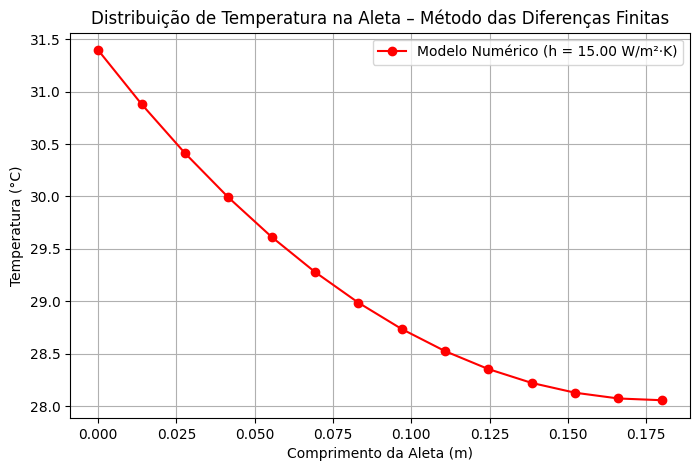

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import math

# ========================
# Parâmetros físicos e geométricos
# ========================
# Comprimento da aleta (m) – use 0.18 se essa for a extensão efetiva da aleta (até a extremidade)
L = 0.18  # m

# Parâmetros do material (já definidos nos itens anteriores)
k = 155         # W/(m·K)
densidade = 2794  # kg/m³
calor_esp = 880   # J/(kg·K)
alpha = k / (densidade * calor_esp)  # Difusividade térmica

# Geometria da aleta (considere uma aleta circular)
raio = 12e-3     # m
perimetro = 2 * math.pi * raio   # m
At = math.pi * (raio**2)           # m²

# Temperaturas de contorno (obtidas dos itens anteriores)
# T_base: temperatura na base da aleta (por exemplo, canal 102)
# T_inf: temperatura ambiente (por exemplo, canal 101)
# Se esses valores já estiverem definidos, use-os. Caso contrário, defina:
T_base = data_medias_distancias.loc[data_medias_distancias["Chanel"] == "102 (°C)"]["T - Mean [˚C]"].values[0]
T_inf = data_medias_distancias.loc[data_medias_distancias["Chanel"] == "101 (°C)"]["T - Mean [˚C]"].values[0]

# Valor do coeficiente de convecção h obtido no exercício 4 
# (se você calculou h_ideal, utilize-o; caso contrário, use um valor estimado, por exemplo 15 W/m²K)
h_val = 15  # W/m²K   (substitua por h_ideal se disponível)

# ========================
# Parâmetros da discretização
# ========================
N = 14
dx = L / (N - 1)    # Espaçamento espacial (m)

# Critério de estabilidade para o esquema explícito:
# Δt <= dx² / (2 * α)
dt_max = dx**2 / (2 * alpha)
# Escolhemos um Δt menor que dt_max para segurança, por exemplo:
dt = 0.1  # s (verifique: deve ser <= dt_max)

print("Δx =", dx, "m")
print("Δt =", dt, "s (dt_max =", dt_max, "s)")

# ========================
# Modelo Numérico – Diferenças Finitas Explícitas para a Equação Transiente
# Considerando a equação:
#    ρc ∂T/∂t = k ∂²T/∂x² - (h P)/(At) (T - T_inf)
# ou, de forma normalizada:
#    T_i^{n+1} = T_i^n + Δt [ α (T_{i+1}^n - 2T_i^n + T_{i-1}^n)/(dx²) - β (T_i^n - T_inf) ]
# onde β = (h P)/(ρ c At)
beta = (h_val * perimetro) / (densidade * calor_esp * At)

# Condição inicial: suponha que inicialmente a aleta esteja uniformemente em T_inf, exceto a base fixada em T_base.
T_old = np.ones(N) * T_inf
T_old[0] = T_base

# Critério de convergência (erro máximo entre iterações)
tol = 1e-6
erro_max = 1.0
iteration = 0
max_iter = 100000

while erro_max > tol and iteration < max_iter:
    T_new = T_old.copy()
    # Atualização dos nós interiores (i = 1 até N-2)
    for i in range(1, N-1):
        T_new[i] = T_old[i] + dt * (alpha * (T_old[i+1] - 2*T_old[i] + T_old[i-1]) / (dx**2) \
                                    - beta * (T_old[i] - T_inf))
    # Condição de contorno na extremidade (x = L) – condição convectiva:
    # Aproximação: (T_N - T_{N-1})/dx = - (h/k) (T_N - T_inf)
    # Resolvendo para T_N:
    T_new[-1] = (T_old[-2] + (h_val * dx / k) * T_inf) / (1 + (h_val * dx / k))
    # A condição na base (x=0) é fixa:
    T_new[0] = T_base

    # Calcula o erro máximo
    erro_max = np.max(np.abs(T_new - T_old))
    T_old = T_new.copy()
    iteration += 1

print("Número de iterações:", iteration)
print("Erro máximo na última iteração:", erro_max)

# ========================
# Plotando a Distribuição de Temperatura (Estado Estacionário)
# ========================
# Gera os pontos espaciais:
x_grid = np.linspace(0, L, N)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, T_new, marker='o', linestyle='-', color='red', 
         label=f'Modelo Numérico (h = {h_val:.2f} W/m²·K)')
plt.xlabel("Comprimento da Aleta (m)")
plt.ylabel("Temperatura (°C)")
plt.title("Distribuição de Temperatura na Aleta – Método das Diferenças Finitas")
plt.legend()
plt.grid(True)
plt.show()

### Resolução e explicação exercício 5:

## Exercício 6

Gráfico 4: Faça um gráfico com as três curvas (Exercício 3,4 e 5). Em sua resposta apenas apresente o gráfico.

### Código para o exercício 6

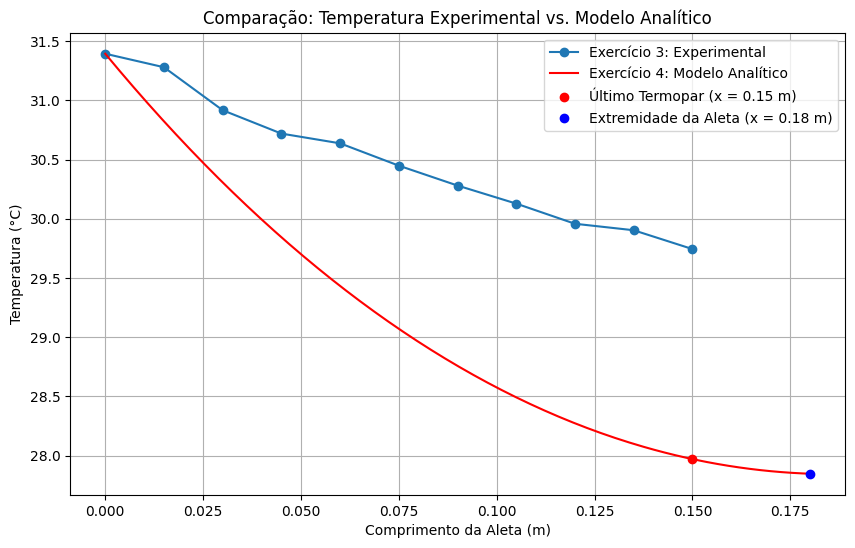

In [17]:

plt.figure(figsize=(10, 6))

# Curva experimental (Exercício 3) - converte a distância de mm para m
plt.plot(graph_ex3["Distance [mm]"] / 1000, graph_ex3["T - Mean [˚C]"],
         marker='o', linestyle='-', label="Exercício 3: Experimental")

# Curva do modelo analítico (Exercício 4)
plt.plot(x, T_x, label="Exercício 4: Modelo Analítico", color='red')
plt.scatter([x_last], [T_last], color='red', zorder=5,
            label=f'Último Termopar (x = {x_last:.2f} m)')
plt.scatter([L], [T_tip], color='blue', zorder=5,
            label=f'Extremidade da Aleta (x = {L:.2f} m)')

plt.xlabel("Comprimento da Aleta (m)")
plt.ylabel("Temperatura (°C)")
plt.title("Comparação: Temperatura Experimental vs. Modelo Analítico")
plt.legend()
plt.grid(True)
plt.show()

### Resolução e explicação exercício 6:

## Exercício 7

### Código para o exercício 7

### Resolução e explicação exercício 7: